## 加州房价


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 加载数据
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # 房价中位数（单位：10万美元）

print(f"样本数: {X.shape[0]}，特征数: {X.shape[1]}")
print(f"目标变量范围: [{y.min():.2f}, {y.max():.2f}]，均值: {y.mean():.2f}")
print(X.head())

样本数: 20640，特征数: 8
目标变量范围: [0.15, 5.00]，均值: 2.07
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## 数据集划分


In [2]:
# 标准化 + 划分数据集
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 训练 baseline 模型
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

for i in range(10):
    print(f"真实值: {y_test[i]}, 预测值: {y_pred[i]}")

训练集: 16512 样本
测试集: 4128 样本
真实值: 0.477, 预测值: 0.719122841601912
真实值: 0.458, 预测值: 1.7640165706624156
真实值: 5.00001, 预测值: 2.709658833431728
真实值: 2.186, 预测值: 2.8389259301839314
真实值: 2.78, 预测值: 2.6046572518103135
真实值: 1.587, 预测值: 2.0117536732498964
真实值: 1.982, 预测值: 2.645500049376658
真实值: 1.575, 预测值: 2.168755321287108
真实值: 3.4, 预测值: 2.7407464411385076
真实值: 4.466, 预测值: 3.9156147250324898


## 模型评估指标


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}  （平均偏差 {mae*10:.2f} 万美元）")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}  （平均偏差 {rmse*10:.2f} 万美元）")
print(f"R²:   {r2:.4f}  （解释了 {r2*100:.1f}% 的方差）")

MAE:  0.5332  （平均偏差 5.33 万美元）
MSE:  0.5559
RMSE: 0.7456  （平均偏差 7.46 万美元）
R²:   0.5758  （解释了 57.6% 的方差）


## 残差分析


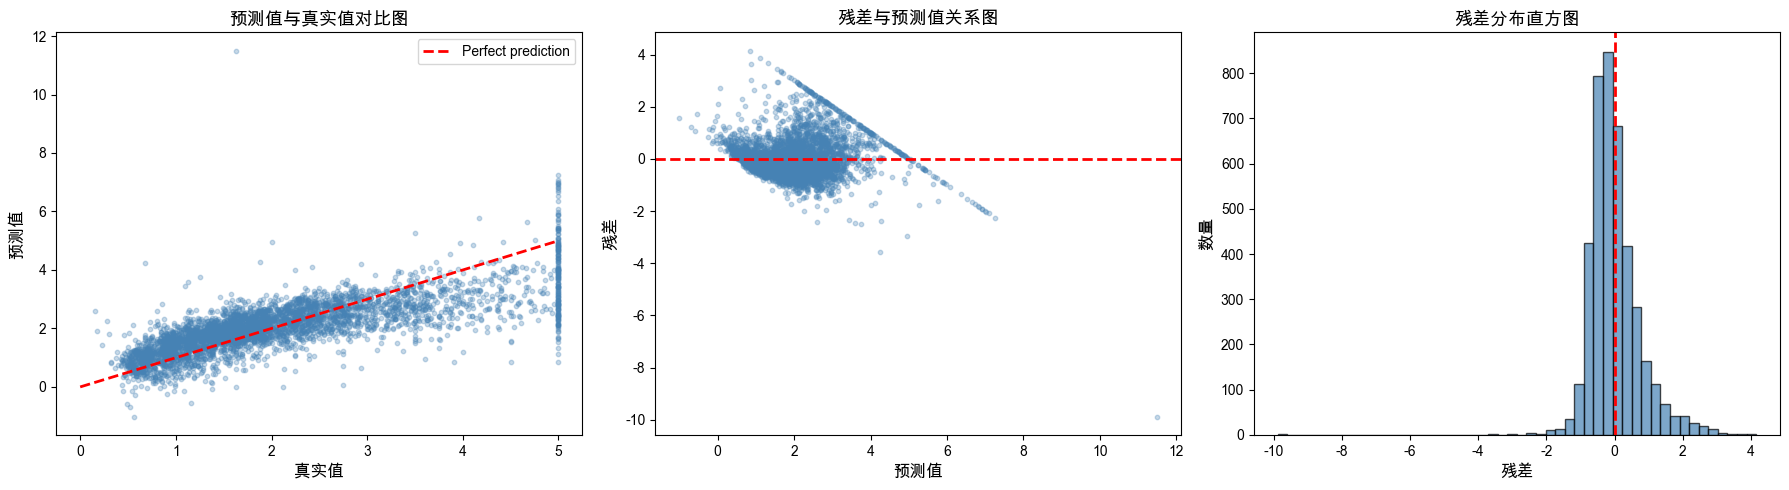

残差均值: 0.0035
残差标准差: 0.7456
残差偏度: 0.5459


In [4]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 图1：预测值 vs 真实值
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('真实值', fontsize=12)
axes[0].set_ylabel('预测值', fontsize=12)
axes[0].set_title('预测值与真实值对比图', fontsize=13)
axes[0].legend()

# 图2：残差 vs 预测值
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('预测值', fontsize=12)
axes[1].set_ylabel('残差', fontsize=12)
axes[1].set_title('残差与预测值关系图', fontsize=13)

# 图3：残差分布
axes[2].hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('残差', fontsize=12)
axes[2].set_ylabel('数量', fontsize=12)
axes[2].set_title('残差分布直方图', fontsize=13)

plt.tight_layout()
plt.show()

# 残差统计
print(f"残差均值: {residuals.mean():.4f}")
print(f"残差标准差: {residuals.std():.4f}")
print(f"残差偏度: {pd.Series(residuals).skew():.4f}")

## K-Fold 交叉验证


In [5]:
from sklearn.model_selection import cross_val_score

# 注意：cross_val_score 会在内部完成 fit 和 predict，不需要手动划分
scores = cross_val_score(
    LinearRegression(), X_scaled, y,
    cv=5,                              # 5 折交叉验证
    scoring='neg_mean_squared_error'   # sklearn 约定：scoring 越大越好，MSE 前面加负号
)

# 将负 MSE 转换回 RMSE
rmse_scores = np.sqrt(-scores)

print("每折 RMSE:")
for i, score in enumerate(rmse_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\n平均 RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

每折 RMSE:
  Fold 1: 0.6963
  Fold 2: 0.7890
  Fold 3: 0.8039
  Fold 4: 0.7370
  Fold 5: 0.7033

平均 RMSE: 0.7459 ± 0.0437


cross validate


In [6]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    LinearRegression(), X_scaled, y,
    cv=5,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    return_train_score=True  # 同时返回训练集上的得分（用于诊断过拟合）
)

print(f"{'指标':<12} {'训练集':>12} {'测试集':>12} {'差距':>10}")
print("-" * 48)
for metric in ['rmse', 'mae', 'r2']:
    train_key = f'train_{metric}'
    test_key = f'test_{metric}'
    
    if metric == 'r2':
        train_mean = cv_results[train_key].mean()
        test_mean = cv_results[test_key].mean()
    else:
        train_mean = -cv_results[train_key].mean()  # 去掉负号
        test_mean = -cv_results[test_key].mean()
    
    gap = abs(train_mean - test_mean)
    print(f"{metric.upper():<12} {train_mean:>12.4f} {test_mean:>12.4f} {gap:>10.4f}")

指标                    训练集          测试集         差距
------------------------------------------------
RMSE               0.7218       0.7459     0.0241
MAE                0.5297       0.5475     0.0178
R2                 0.6071       0.5530     0.0541
